# 7. Complex Geometry (Tiers 3a & 3b)

This notebook demonstrates the Tier 3 procedural geometry generators and verifies
that navmesh pathfinding works correctly on cluttered, multi-room layouts.

**Tier 3a** — Base room (Tier 0–2) populated with internal obstacles (columns,
furniture blocks) and 1–2 door openings. Optionally, all agents share a single
goal area (evacuation mode).

**Tier 3b** — 2–3 rooms from Tiers 0–2, composed side-by-side and connected via
corridor links. Obstacles are placed inside rooms. 1–2 exterior evacuation doors
serve as goal regions.

**Key things to verify:**
- Polygon validity (no self-intersections, positive area)
- Obstacles appear as polygon holes
- Spawn/goal regions overlap the walkable area
- Navmesh construction succeeds
- A* + funnel pathfinding navigates around obstacles

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Polygon

from crowdrl_core.geometry import (
    build_navmesh,
    extract_wall_segments,
    sample_point_in_polygon,
)
from crowdrl_core.navmesh import (
    find_path,
    is_reachable,
    shortest_path,
    path_deviation,
)
from crowdrl_env.geometry_generator import (
    GeometryConfig,
    GeometryTier,
    generate_geometry,
    generate_tier3a,
    generate_tier3b,
)
from crowdrl_env.visualiser import (
    plot_geometry,
    plot_navmesh,
    plot_spawn_goal_regions,
    visualise_generated_geometry,
)

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

## Tier 3a — Rooms with Obstacles

Each geometry starts from a Tier 0–2 base room, adds random obstacles
(columns and rectangular furniture), and cuts 1–2 door openings.
When `shared_goal` is active, all agents target a single exit door.

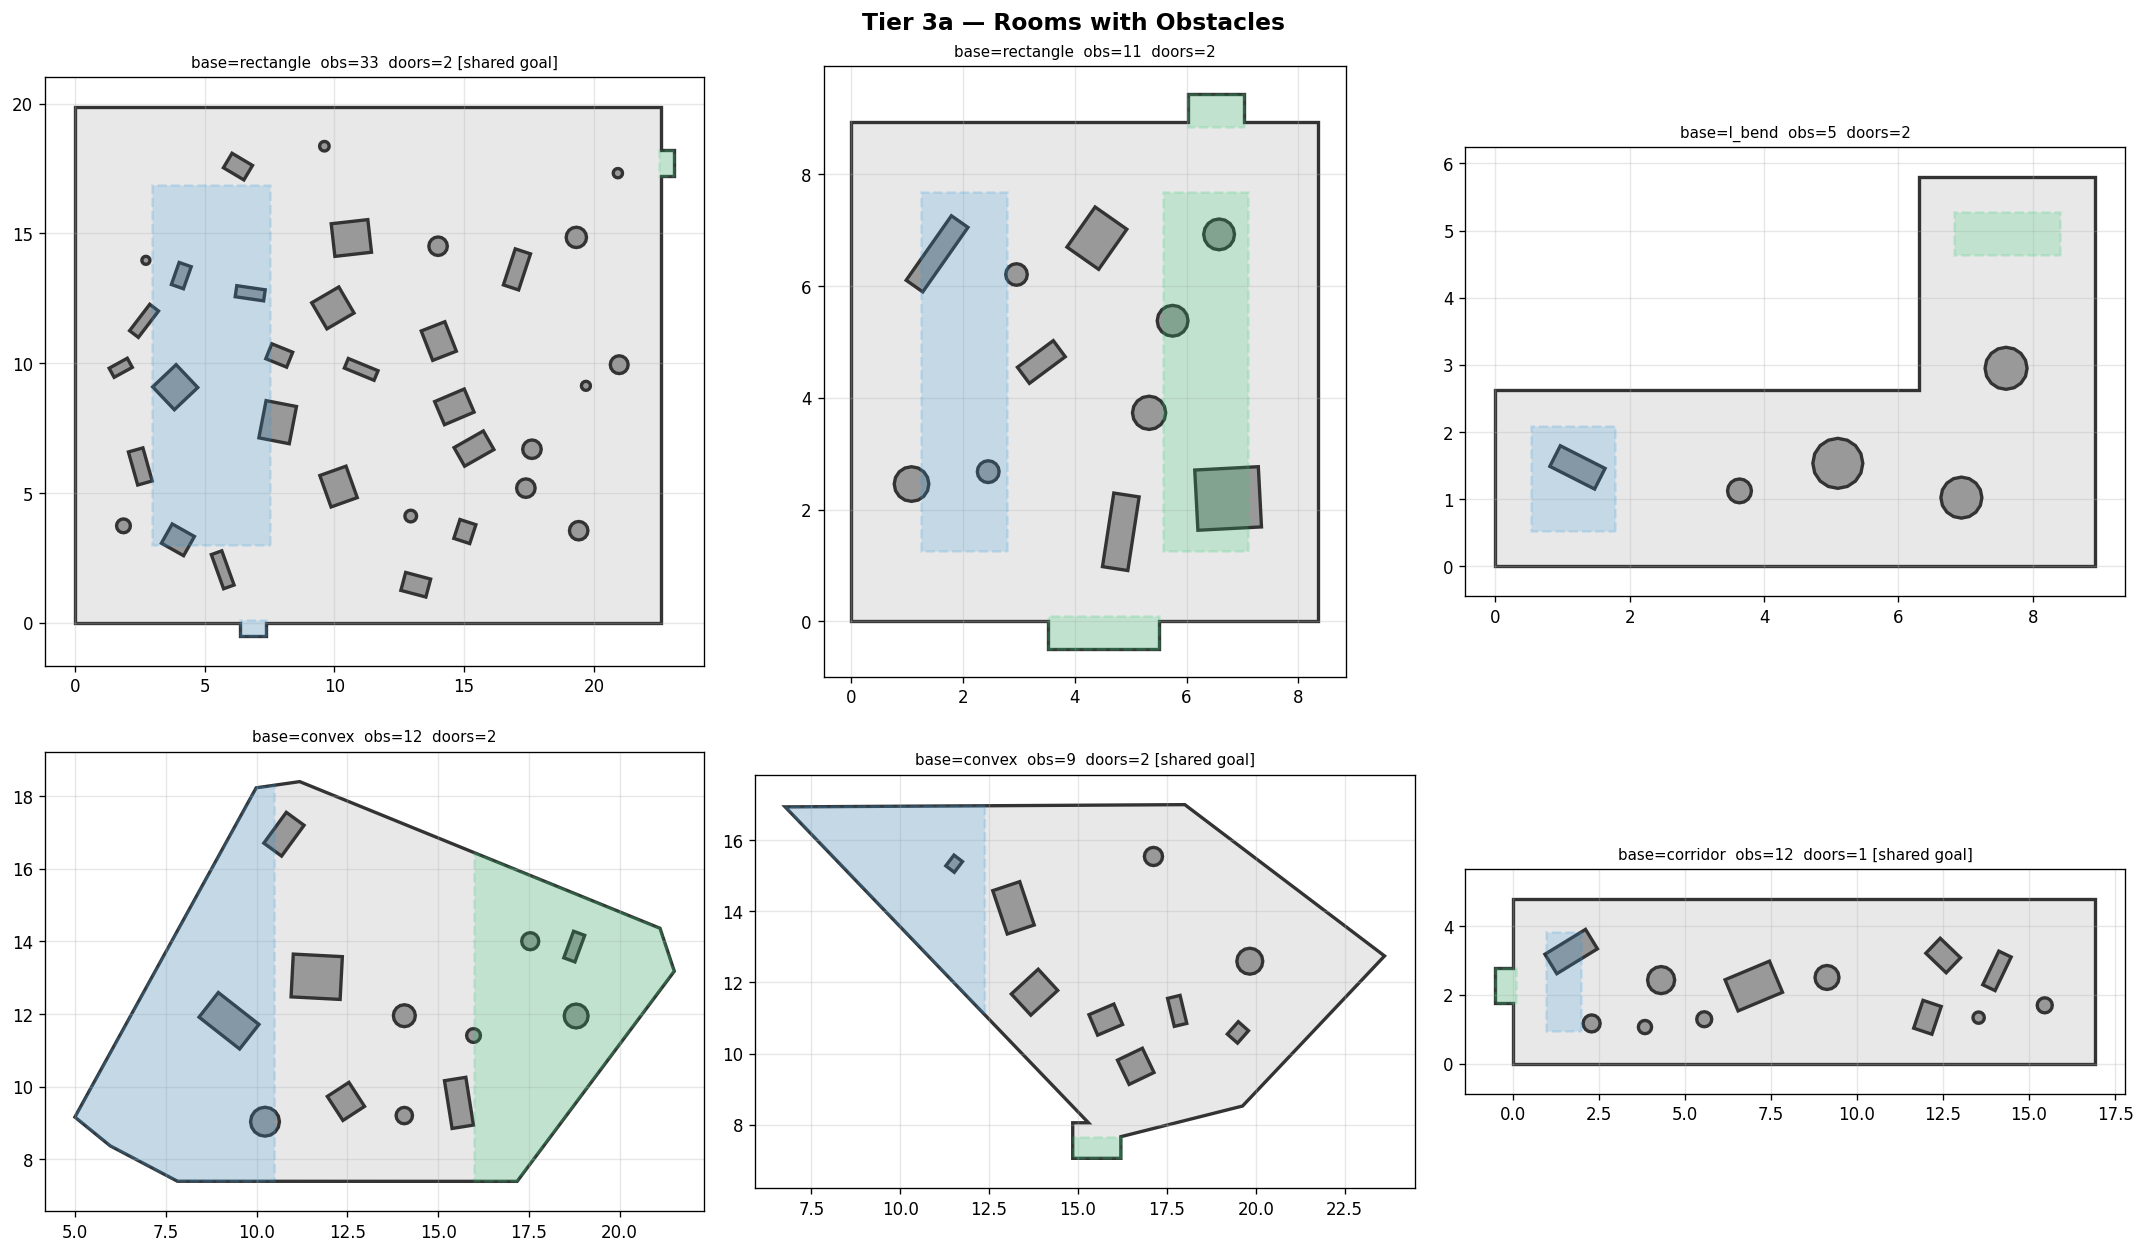

In [2]:
rng = np.random.default_rng(42)
config = GeometryConfig(tier=GeometryTier.TIER_3A)

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
for ax in axes.flat:
    geom = generate_geometry(rng, config)
    plot_geometry(geom.polygon, ax=ax)
    plot_spawn_goal_regions(geom, ax)
    base = geom.metadata.get("base_shape", "?")
    n_obs = geom.metadata.get("n_obstacles", 0)
    n_doors = geom.metadata.get("n_doors", 0)
    shared = " [shared goal]" if geom.metadata.get("shared_goal") else ""
    ax.set_title(
        f"base={base}  obs={n_obs}  doors={n_doors}{shared}",
        fontsize=9,
    )

fig.suptitle("Tier 3a \u2014 Rooms with Obstacles", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Tier 3a with forced shared goal (evacuation mode)

Setting `shared_goal_probability=1.0` ensures every geometry has a single
goal region — all agents must reach the same exit door.

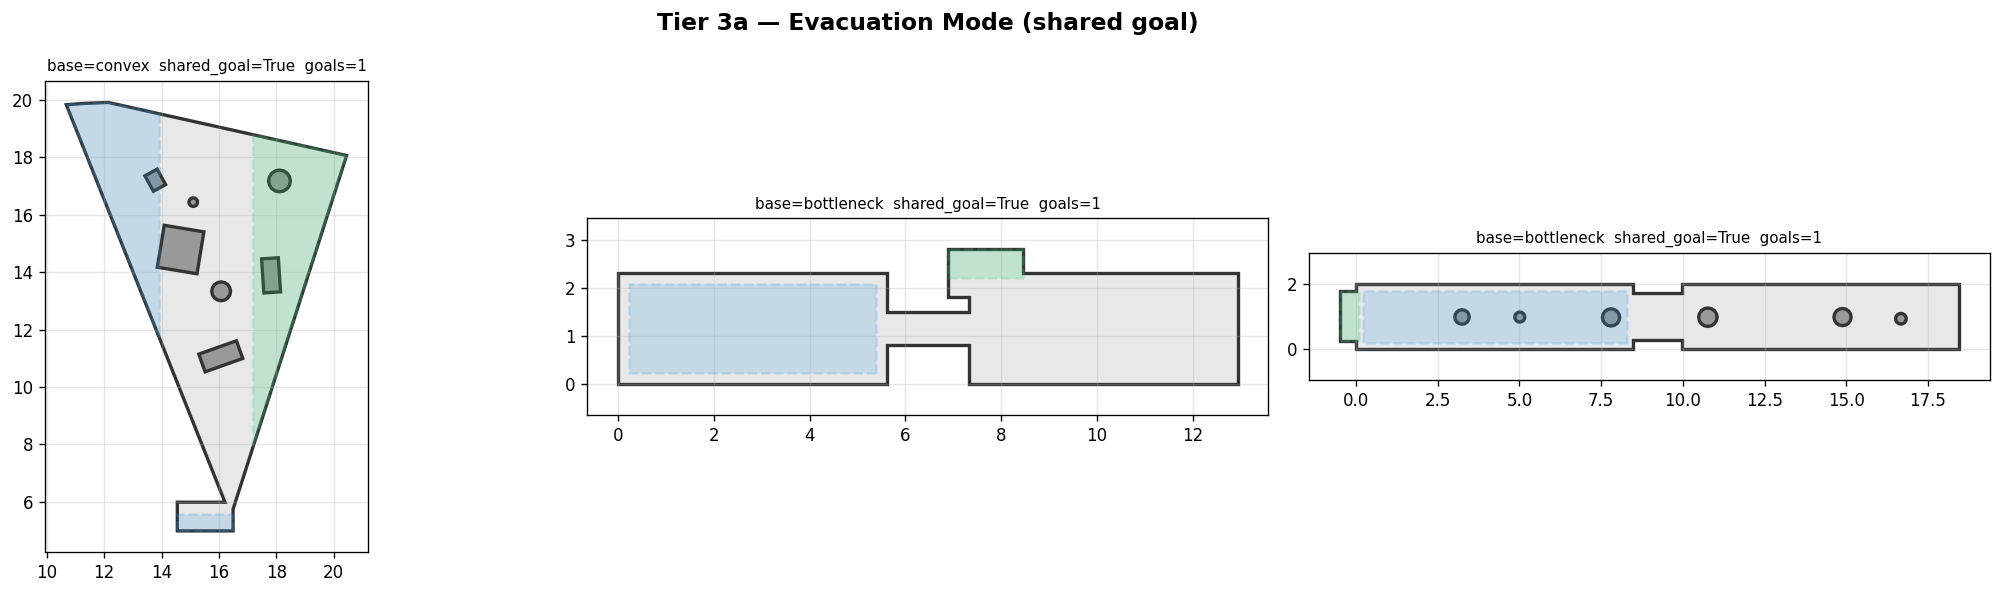

In [3]:
config_evac = GeometryConfig(
    tier=GeometryTier.TIER_3A,
    shared_goal_probability=1.0,
    obstacle_coverage_range=(0.08, 0.15),
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax in axes.flat:
    geom = generate_tier3a(rng, config_evac)
    plot_geometry(geom.polygon, ax=ax)
    plot_spawn_goal_regions(geom, ax)
    shared = geom.metadata.get("shared_goal", False)
    ax.set_title(
        f"base={geom.metadata['base_shape']}  shared_goal={shared}  "
        f"goals={len(geom.goal_regions)}",
        fontsize=9,
    )

fig.suptitle("Tier 3a \u2014 Evacuation Mode (shared goal)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Tier 3b — Composed Multi-Room Layouts

Multiple rooms from Tiers 0–2 are arranged side-by-side and connected via
corridor links. Obstacles are scattered inside, and 1–2 exterior evacuation
doors are cut.

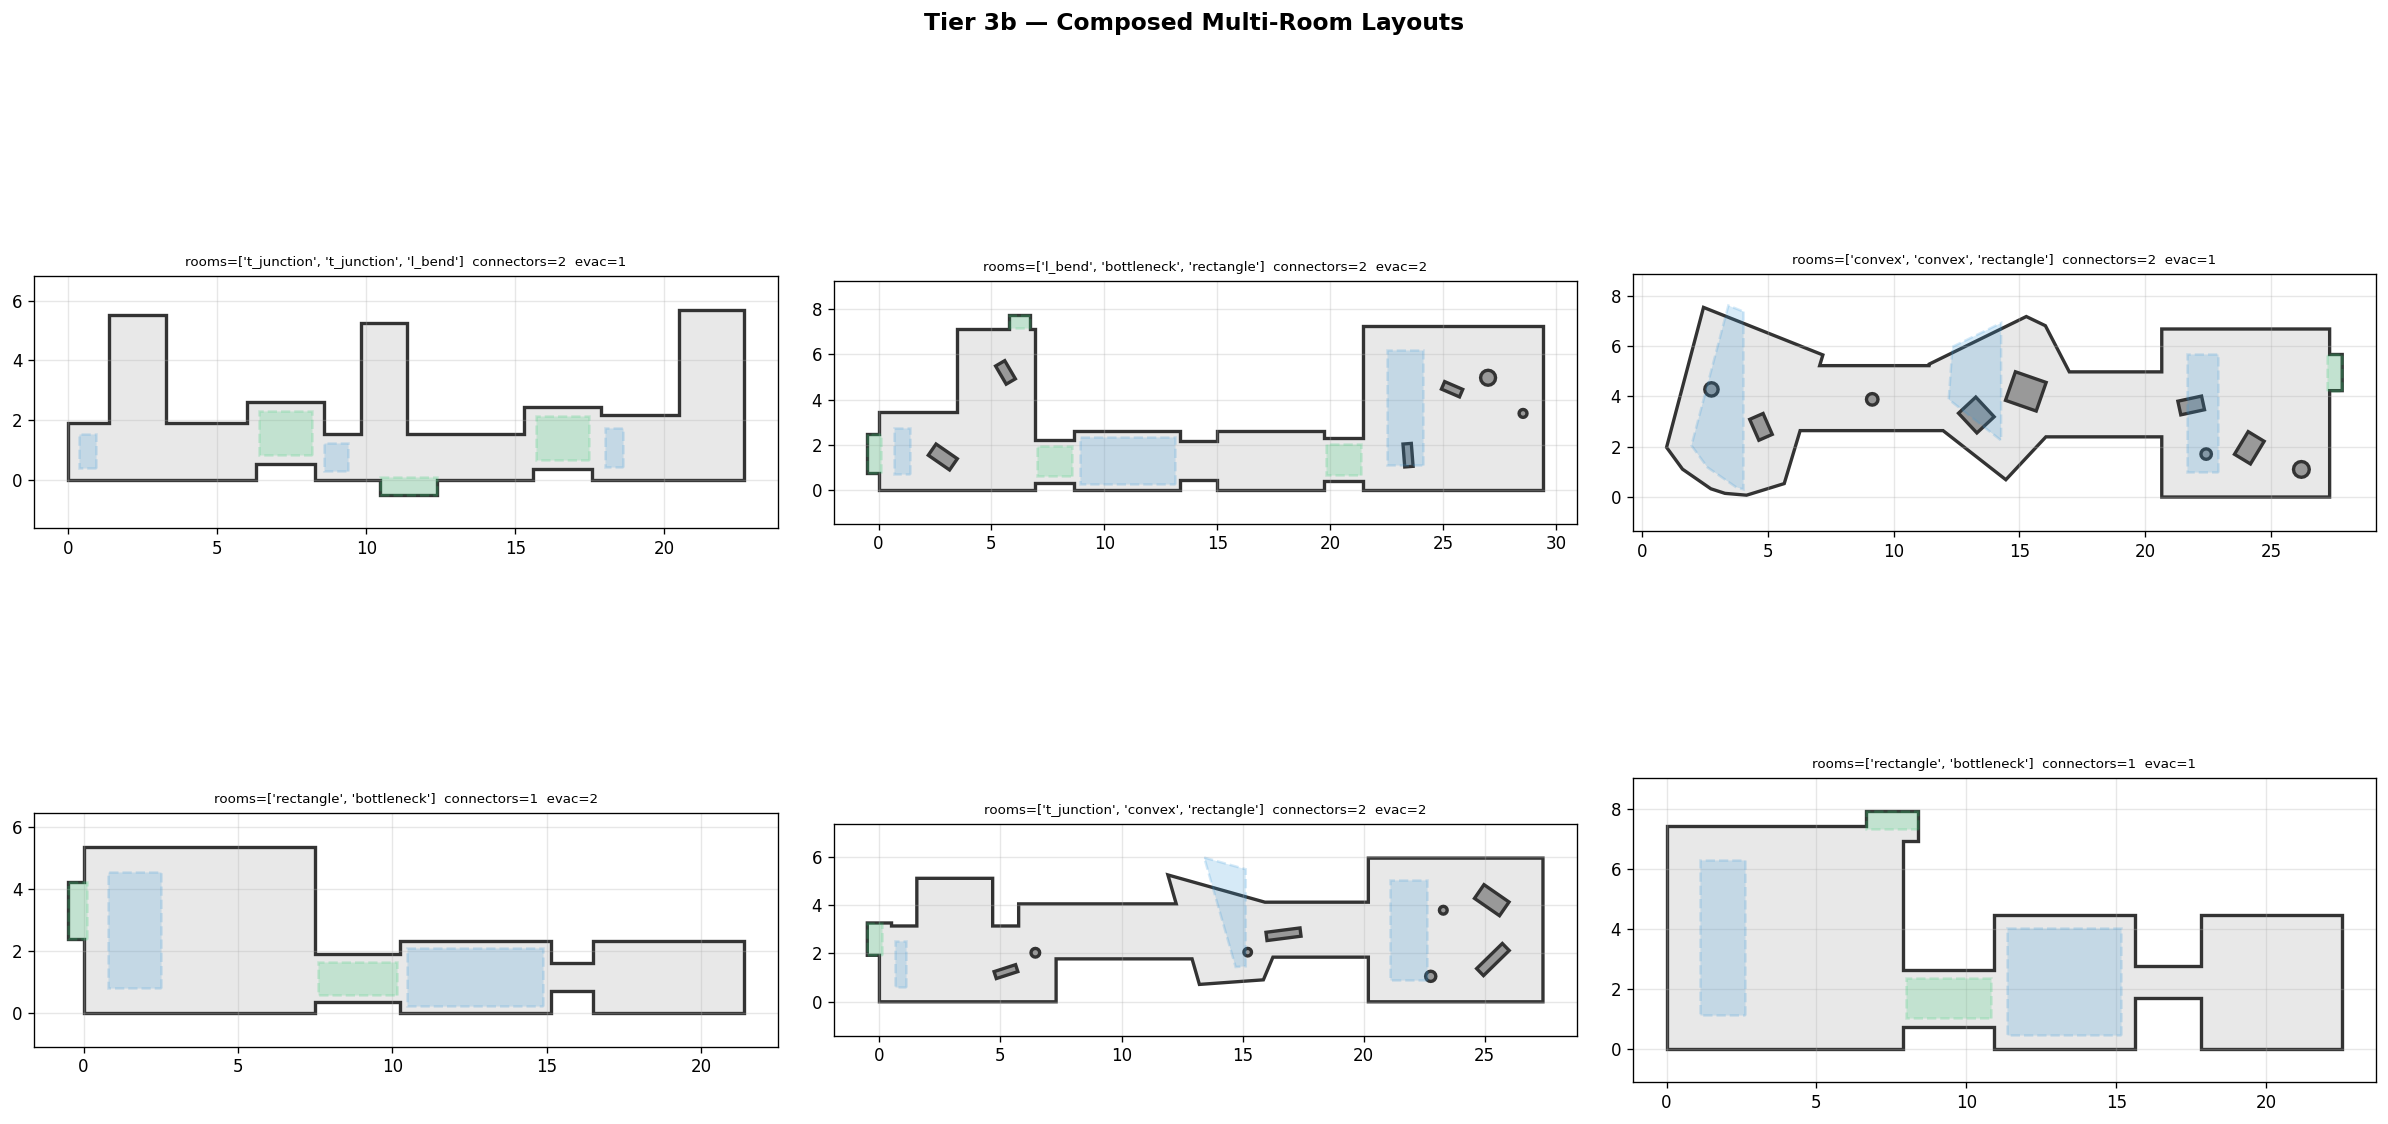

In [4]:
config_3b = GeometryConfig(tier=GeometryTier.TIER_3B)

fig, axes = plt.subplots(2, 3, figsize=(20, 11))
for ax in axes.flat:
    geom = generate_geometry(rng, config_3b)
    plot_geometry(geom.polygon, ax=ax)
    plot_spawn_goal_regions(geom, ax)
    rooms = geom.metadata.get("room_shapes", [])
    n_conn = geom.metadata.get("n_connectors", 0)
    n_evac = geom.metadata.get("n_evac_doors", 0)
    ax.set_title(
        f"rooms={rooms}  connectors={n_conn}  evac={n_evac}",
        fontsize=8,
    )

fig.suptitle("Tier 3b \u2014 Composed Multi-Room Layouts", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Tier 3b with 3 rooms

Force 3-room composition to see larger floor plans.

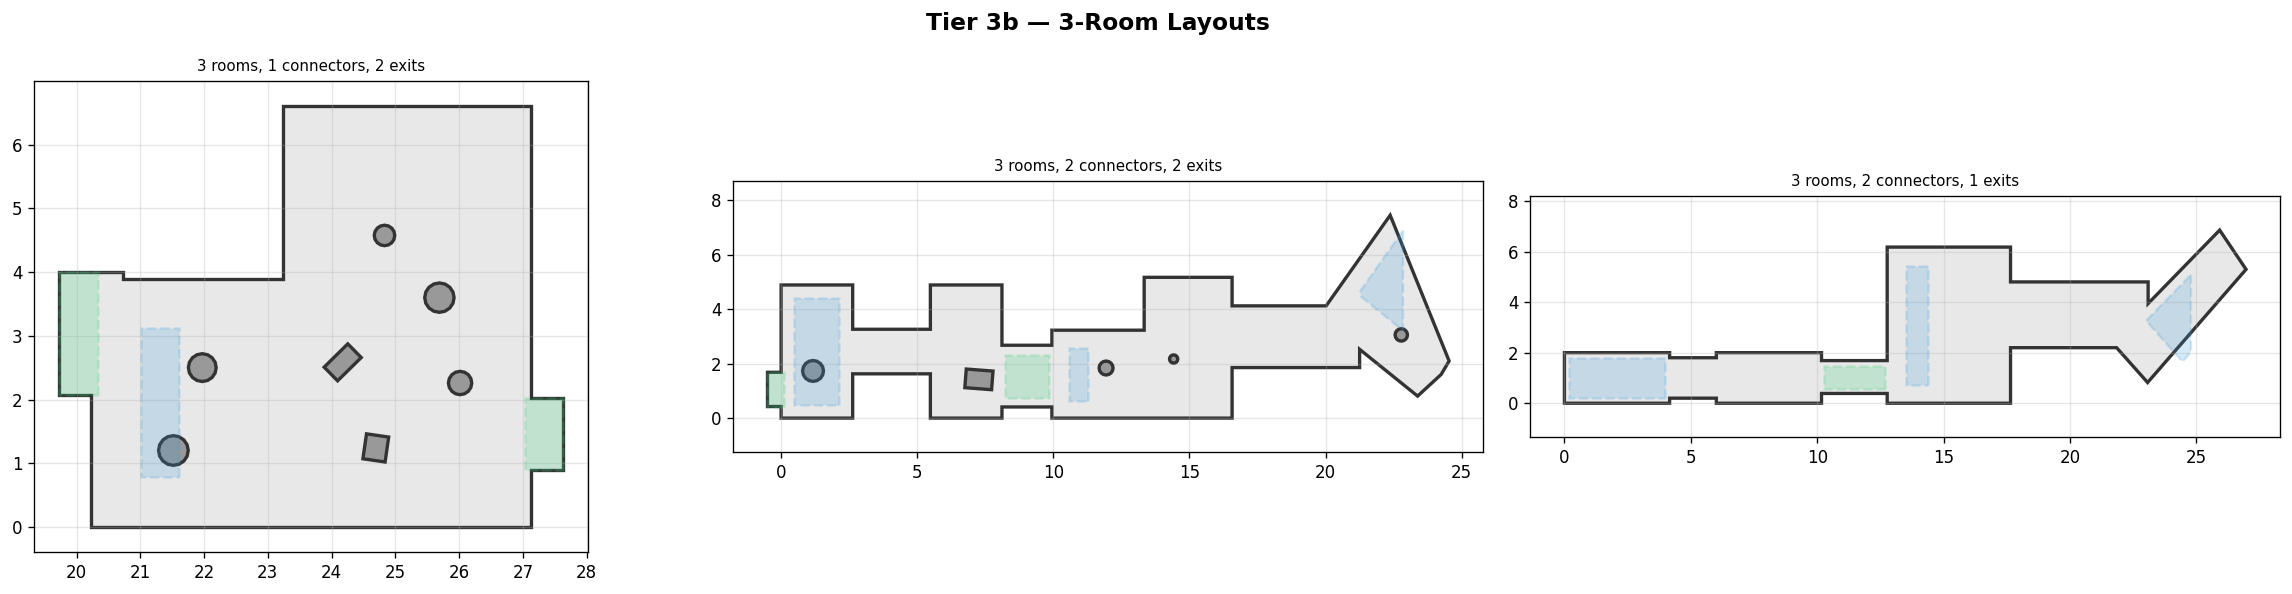

In [5]:
config_3rooms = GeometryConfig(
    tier=GeometryTier.TIER_3B,
    n_rooms_range=(3, 3),
    obstacle_coverage_range=(0.05, 0.12),
)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax in axes.flat:
    geom = generate_tier3b(rng, config_3rooms)
    plot_geometry(geom.polygon, ax=ax)
    plot_spawn_goal_regions(geom, ax)
    ax.set_title(
        f"{geom.metadata['n_rooms']} rooms, {geom.metadata['n_connectors']} connectors, "
        f"{geom.metadata['n_evac_doors']} exits",
        fontsize=9,
    )

fig.suptitle("Tier 3b \u2014 3-Room Layouts", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Navmesh Construction on Tier 3

The constrained Delaunay triangulation must handle polygon holes (obstacles).
Let's verify that navmesh construction succeeds and visualise the result.

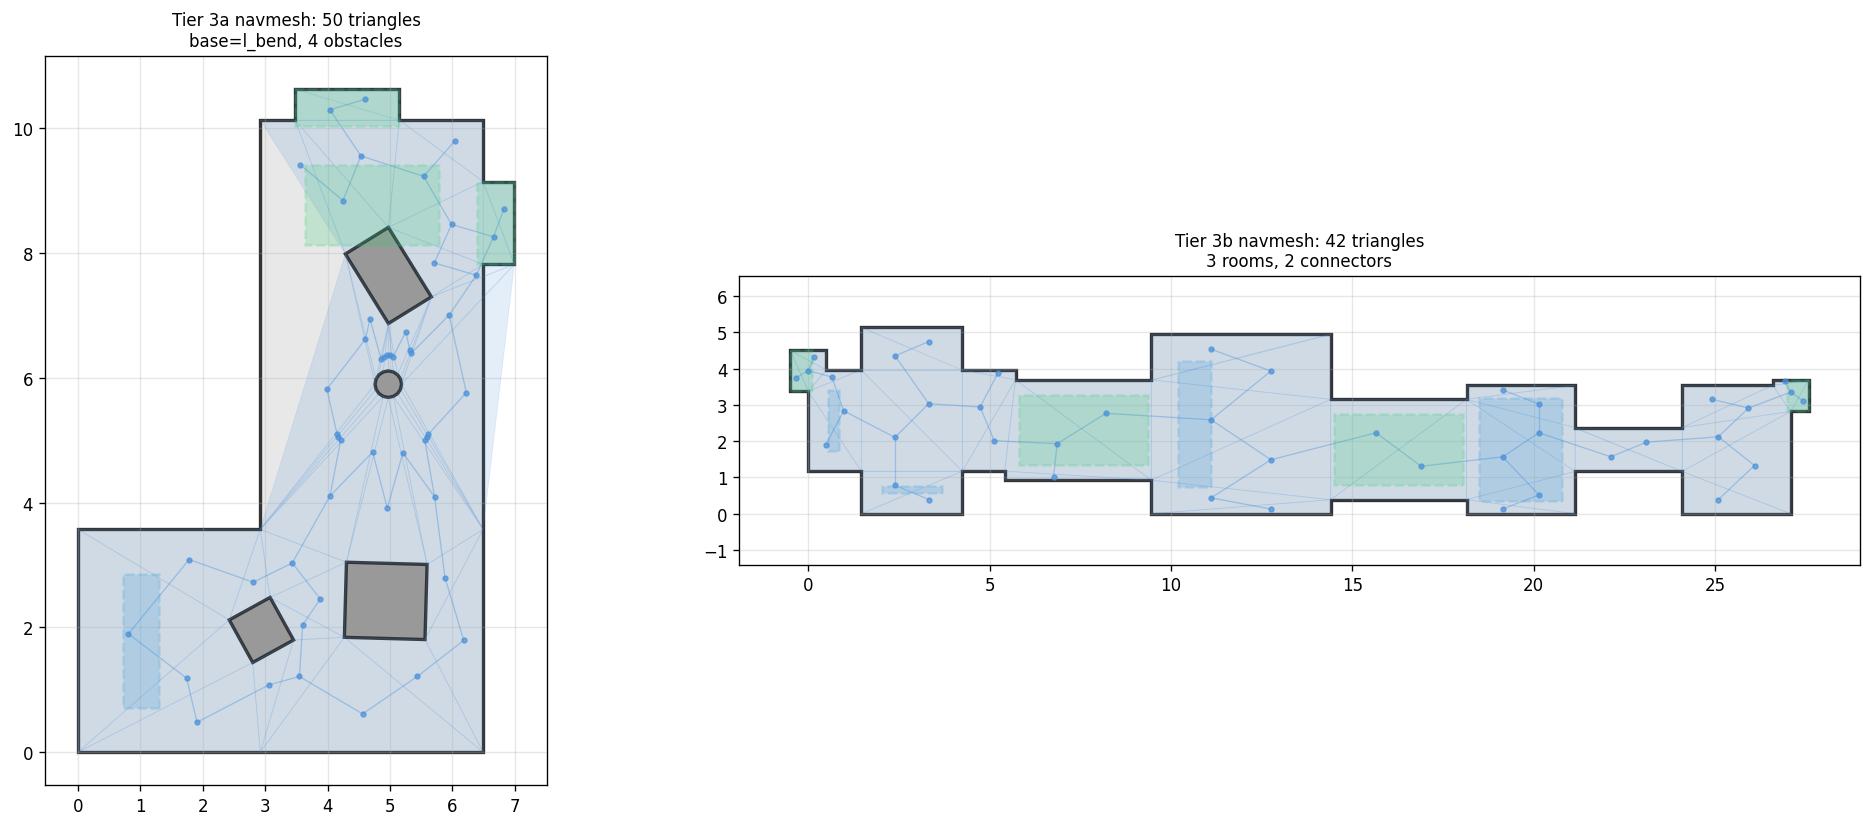

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Tier 3a with navmesh
geom_3a = generate_tier3a(np.random.default_rng(10), GeometryConfig(tier=GeometryTier.TIER_3A))
nm_3a = build_navmesh(geom_3a.polygon)
visualise_generated_geometry(geom_3a, show_navmesh=True, navmesh=nm_3a, ax=axes[0])
axes[0].set_title(
    f"Tier 3a navmesh: {len(nm_3a.triangles)} triangles\n"
    f"base={geom_3a.metadata['base_shape']}, {geom_3a.metadata['n_obstacles']} obstacles",
    fontsize=10,
)

# Tier 3b with navmesh
geom_3b = generate_tier3b(np.random.default_rng(5), GeometryConfig(tier=GeometryTier.TIER_3B))
nm_3b = build_navmesh(geom_3b.polygon)
visualise_generated_geometry(geom_3b, show_navmesh=True, navmesh=nm_3b, ax=axes[1])
axes[1].set_title(
    f"Tier 3b navmesh: {len(nm_3b.triangles)} triangles\n"
    f"{geom_3b.metadata['n_rooms']} rooms, {geom_3b.metadata['n_connectors']} connectors",
    fontsize=10,
)

plt.tight_layout()
plt.show()

## Shortest Path through Obstacles

A* finds the triangle corridor through the navmesh; the funnel algorithm
computes the geometrically shortest path around obstacles and through
corridor connections. Agent clearance (r=0.2m) keeps paths away from walls.

In [7]:
AGENT_RADIUS = 0.2


def plot_shortest_path(navmesh, start, goal, ax, agent_radius=AGENT_RADIUS):
    """Visualise the funnel-smoothed shortest path with agent clearance."""
    tri_path = find_path(navmesh, start, goal)
    if tri_path is None:
        ax.set_title("No path found!", color="red")
        return

    # A* centroid path (faint)
    centroids_path = np.array(
        [start] + [navmesh.centroids[i] for i in tri_path] + [goal]
    )
    ax.plot(
        centroids_path[:, 0], centroids_path[:, 1],
        "o--", color="#bdc3c7", linewidth=1.5, markersize=3,
        zorder=10, alpha=0.7, label="A* centroids",
    )

    # Taut string (zero radius)
    wp_exact = shortest_path(navmesh, start, goal, agent_radius=0.0)
    if wp_exact is not None and len(wp_exact) >= 2:
        wp0 = np.array(wp_exact)
        ax.plot(
            wp0[:, 0], wp0[:, 1], "o--", color="#f39c12",
            linewidth=1.5, markersize=3, zorder=12, alpha=0.6,
            label="Taut string (r=0)",
        )

    # Agent-radius path
    waypoints = shortest_path(navmesh, start, goal, agent_radius=agent_radius)
    if waypoints is not None and len(waypoints) >= 2:
        wp = np.array(waypoints)
        ax.plot(
            wp[:, 0], wp[:, 1], "o-", color="#e74c3c",
            linewidth=2.5, markersize=5, zorder=15,
            label=f"Shortest path (r={agent_radius}m)",
        )

    ax.plot(*start, "s", color="#3498db", markersize=12, zorder=20, label="Start")
    ax.plot(*goal, "*", color="#2ecc71", markersize=15, zorder=20, label="Goal")

    dev = path_deviation(navmesh, start, goal, agent_radius=agent_radius)
    n_wp = len(waypoints) if waypoints else 0
    ax.set_title(
        f"{len(tri_path)} triangles, {n_wp} waypoints, deviation={dev:.3f}",
        fontsize=10,
    )
    ax.legend(fontsize=7, loc="upper right")

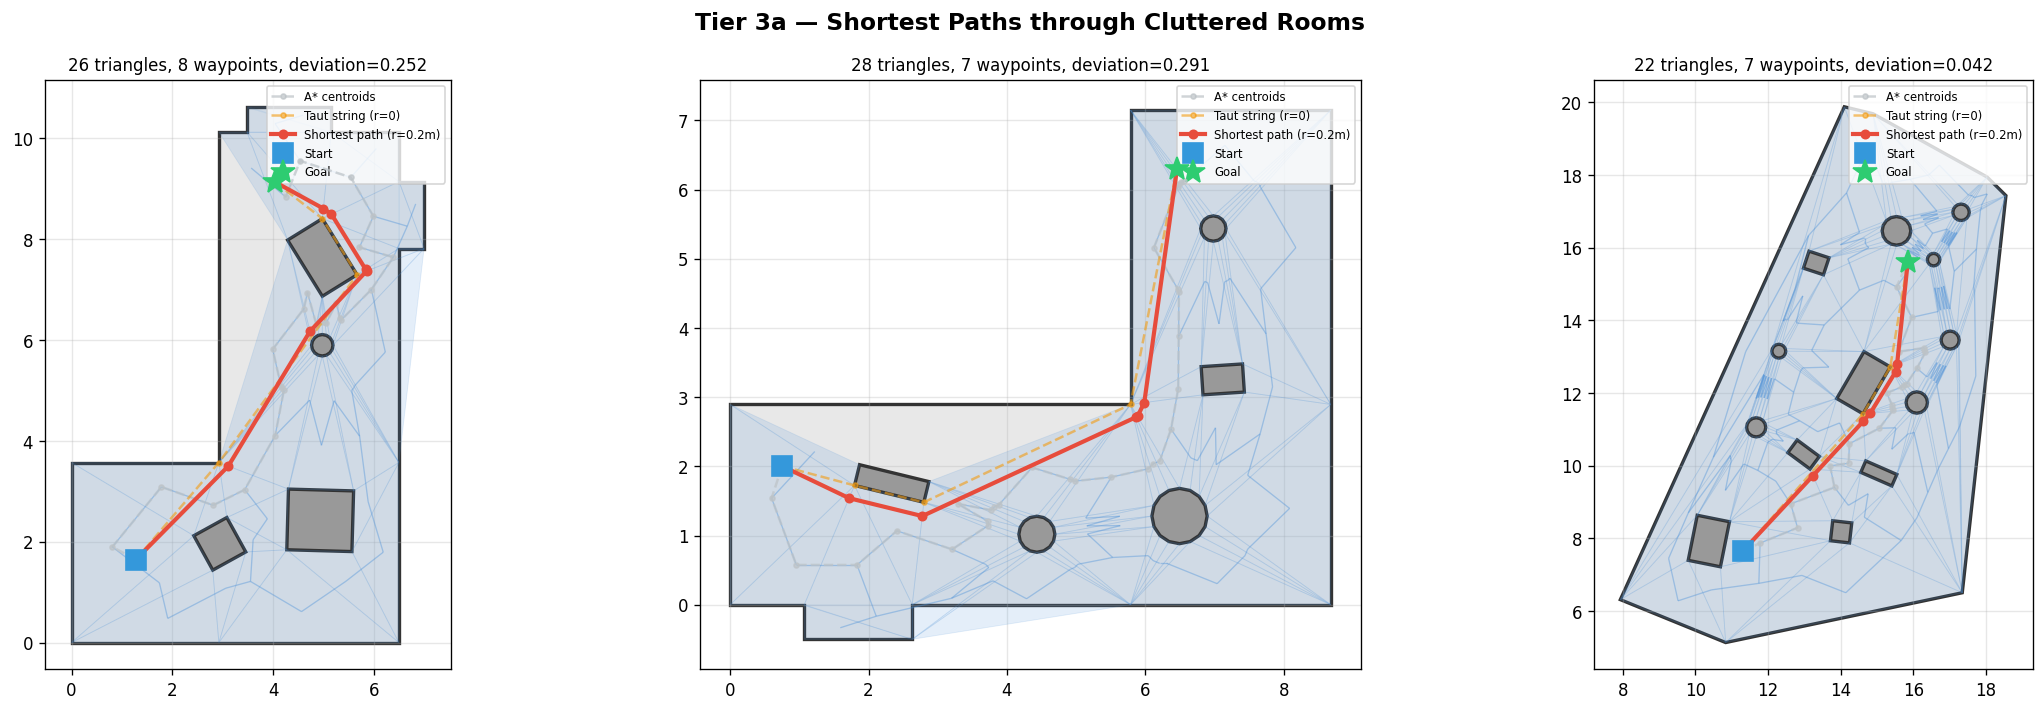

In [8]:
# Tier 3a paths
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, seed in zip(axes, [10, 17, 23]):
    r = np.random.default_rng(seed)
    geom = generate_tier3a(r, GeometryConfig(tier=GeometryTier.TIER_3A))
    nm = build_navmesh(geom.polygon)

    start = sample_point_in_polygon(geom.spawn_regions[0], r)
    goal = sample_point_in_polygon(geom.goal_regions[0], r)

    plot_geometry(geom.polygon, ax=ax)
    plot_navmesh(nm, ax, show_adjacency=True)
    plot_shortest_path(nm, start, goal, ax)

fig.suptitle(
    "Tier 3a \u2014 Shortest Paths through Cluttered Rooms",
    fontsize=14, fontweight="bold",
)
plt.tight_layout()
plt.show()

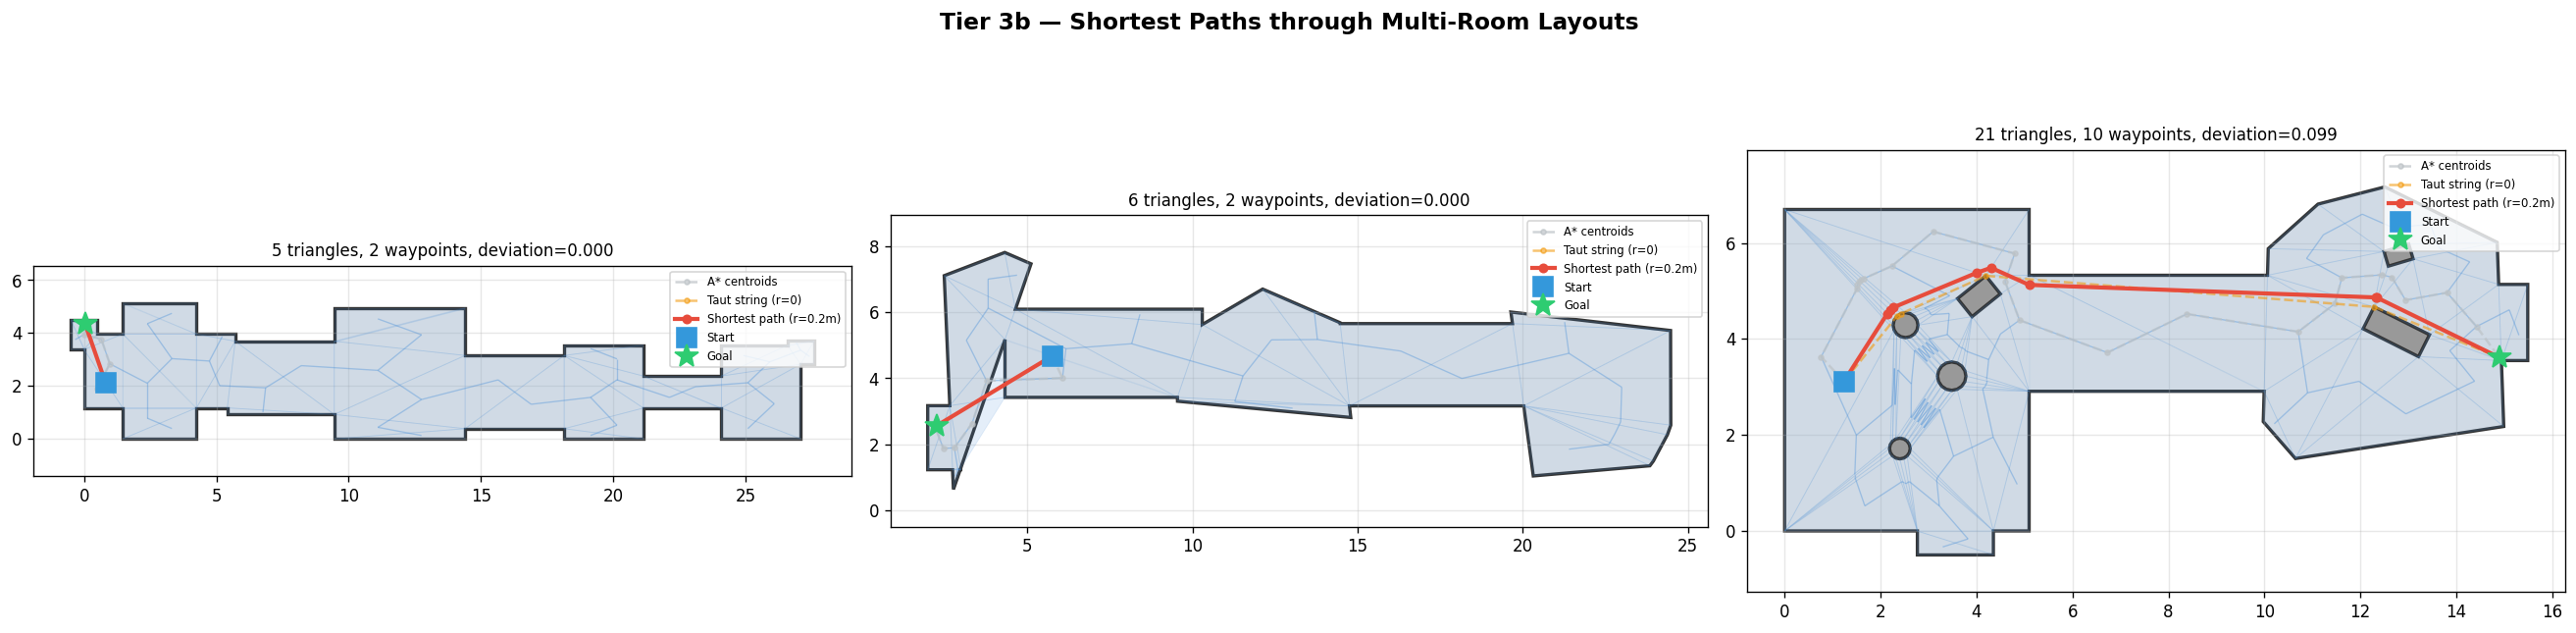

In [9]:
# Tier 3b paths
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

for ax, seed in zip(axes, [5, 12, 30]):
    r = np.random.default_rng(seed)
    geom = generate_tier3b(r, GeometryConfig(tier=GeometryTier.TIER_3B))
    nm = build_navmesh(geom.polygon)

    start = sample_point_in_polygon(geom.spawn_regions[0], r)
    goal = sample_point_in_polygon(geom.goal_regions[0], r)

    plot_geometry(geom.polygon, ax=ax)
    plot_navmesh(nm, ax, show_adjacency=True)
    plot_shortest_path(nm, start, goal, ax)

fig.suptitle(
    "Tier 3b \u2014 Shortest Paths through Multi-Room Layouts",
    fontsize=14, fontweight="bold",
)
plt.tight_layout()
plt.show()

## Solvability Check

Verify that spawn-to-goal paths exist for Tier 3 geometries.
Complex layouts with obstacles may occasionally produce unreachable pairs,
which the solvability verifier handles via pruning or regeneration.

In [10]:
n_tests = 30
n_pairs = 20

for tier_name, tier in [("3a", GeometryTier.TIER_3A), ("3b", GeometryTier.TIER_3B)]:
    rng_test = np.random.default_rng(99)
    config = GeometryConfig(tier=tier)
    results = []
    for _ in range(n_tests):
        geom = generate_geometry(rng_test, config)
        nm = build_navmesh(geom.polygon)
        reachable = 0
        for _ in range(n_pairs):
            s = sample_point_in_polygon(geom.spawn_regions[0], rng_test)
            g = sample_point_in_polygon(geom.goal_regions[0], rng_test)
            if is_reachable(nm, s, g):
                reachable += 1
        results.append(reachable / n_pairs)

    print(f"Tier {tier_name} solvability across {n_tests} geometries ({n_pairs} pairs each):")
    print(f"  Mean: {np.mean(results):.1%}")
    print(f"  Min:  {np.min(results):.1%}")
    print(f"  Max:  {np.max(results):.1%}")
    print()

Tier 3a solvability across 30 geometries (20 pairs each):
  Mean: 92.7%
  Min:  70.0%
  Max:  100.0%

Tier 3b solvability across 30 geometries (20 pairs each):
  Mean: 81.8%
  Min:  0.0%
  Max:  100.0%



## Geometry Statistics

Summary statistics across many generated geometries: area, number of obstacles
(polygon holes), wall segment count, and navmesh triangle count.

In [11]:
rng_stats = np.random.default_rng(0)
n_samples = 50

for tier_name, tier in [("3a", GeometryTier.TIER_3A), ("3b", GeometryTier.TIER_3B)]:
    areas, n_holes, n_walls, n_tris = [], [], [], []
    config = GeometryConfig(tier=tier)
    for _ in range(n_samples):
        geom = generate_geometry(rng_stats, config)
        nm = build_navmesh(geom.polygon)
        ws = extract_wall_segments(geom.polygon)
        areas.append(geom.polygon.area)
        n_holes.append(len(list(geom.polygon.interiors)))
        n_walls.append(ws.shape[0])
        n_tris.append(len(nm.triangles))

    print(f"--- Tier {tier_name} ({n_samples} samples) ---")
    print(f"  Area:       {np.mean(areas):6.1f} +/- {np.std(areas):5.1f} m^2")
    print(f"  Holes:      {np.mean(n_holes):6.1f} +/- {np.std(n_holes):5.1f}")
    print(f"  Wall segs:  {np.mean(n_walls):6.1f} +/- {np.std(n_walls):5.1f}")
    print(f"  Triangles:  {np.mean(n_tris):6.1f} +/- {np.std(n_tris):5.1f}")
    print()

--- Tier 3a (50 samples) ---
  Area:         89.1 +/-  81.3 m^2
  Holes:         8.6 +/-   8.2
  Wall segs:   104.9 +/-  81.2
  Triangles:   120.2 +/-  98.1

--- Tier 3b (50 samples) ---
  Area:         79.9 +/-  24.1 m^2
  Holes:         3.5 +/-   3.7
  Wall segs:    66.9 +/-  41.0
  Triangles:    72.1 +/-  47.8

